In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from sklearn.svm import SVC
# Preprocessing & Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)


In [2]:
data = pd.read_csv('clean.csv')

Dataset loaded: 11000 rows, 20 columns
Features (X): 18 columns
Target (y) distribution:
Anxiety_Class
0    5202
1    4661
2    1137
Name: count, dtype: int64

Class balance ratio (%):
Anxiety_Class
0    47.29
1    42.37
2    10.34
Name: count, dtype: float64

Class balance ratio: 5202:4661:1137 (Low : Moderate : High)


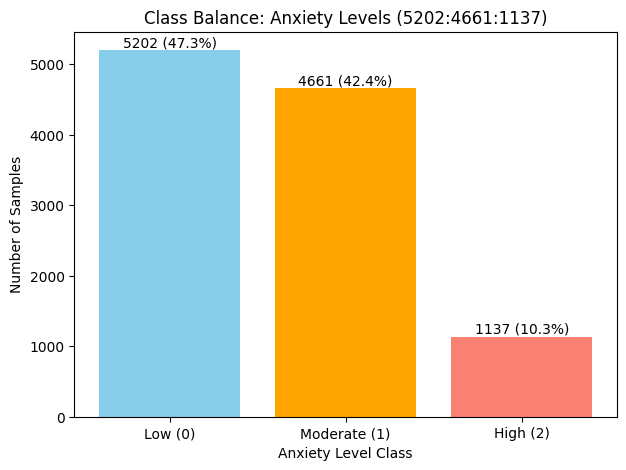

In [3]:
def anxiety_category(x):
    if x <= 3:
        return 0  # Low
    elif x <= 6:
        return 1  # Moderate
    else:
        return 2  # High

data["Anxiety_Class"] = data["Anxiety Level (1-10)"].apply(anxiety_category)
X = data.drop(["Anxiety Level (1-10)", "Anxiety_Class"], axis=1)
y = data["Anxiety_Class"]

# --- Counts and ratios ---
counts = y.value_counts().sort_index()
class_ratio = counts / counts.sum()

# Simplified ratio
g = gcd(counts[0], counts[1]) if len(counts) > 1 else 1
ratio_str = ':'.join(str(counts[i]//g) for i in range(len(counts)))

# --- Print info ---
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y) distribution:\n{counts}")
print("\nClass balance ratio (%):")
print((class_ratio * 100).round(2))
print(f"\nClass balance ratio: {ratio_str} (Low : Moderate : High)")

# --- Plot ---
plt.figure(figsize=(7,5))
bars = plt.bar(counts.index.astype(str), counts.values, color=['skyblue','orange','salmon'])
plt.title(f"Class Balance: Anxiety Levels ({ratio_str})")
plt.xlabel("Anxiety Level Class")
plt.ylabel("Number of Samples")
plt.xticks([0,1,2], ["Low (0)", "Moderate (1)", "High (2)"])

# Add count + percentage on top
for bar, ratio in zip(bars, class_ratio):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f"{int(height)} ({ratio*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.show()

Identify categorical and numeric columns

In [4]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

ONEHOTENCODING AND FEASURE SCALING

In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

SPLITTING THE DATASET INTO TEST AND TRAIN SET

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


MODEL PIPELINES

In [7]:
pipelines = {
    "logreg": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",          
            random_state=42
        ))
    ]),

    "svm": Pipeline([
        ("preprocess", preprocess),
        ("model", SVC(
            C=1,
            kernel="linear",
            class_weight="balanced",
            probability=True,          
            random_state=42
        ))
    ]),

    "xgb": Pipeline([
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            objective="multi:softprob", 
            num_class=3,
            eval_metric="mlogloss",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "mlp": Pipeline([
        ("preprocess", preprocess),
        ("scaler", StandardScaler()),  # MLP needs scaled features
        ("model", MLPClassifier(
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ])
}

In [8]:
param_grids = {
    "logreg": {
        "model__C": [0.01, 0.1, 1]
    },
    "svm": {
        "model__C": [0.01, 0.1, 1]
    },
    "xgb": {
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [200]
    },
    "mlp": {
        "model__hidden_layer_sizes": [(50,), (100,)],
        "model__alpha": [0.0001, 0.001]
    }
}


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [10]:
results = {}

for name in pipelines:
    grid = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    results[name] = grid


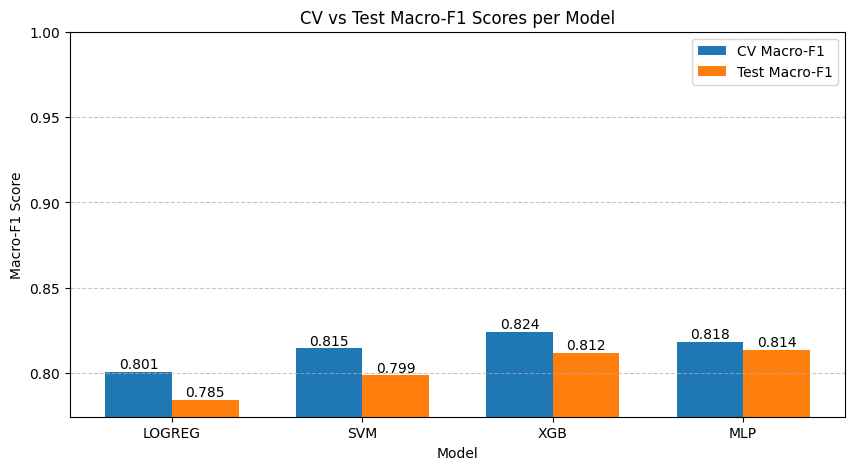

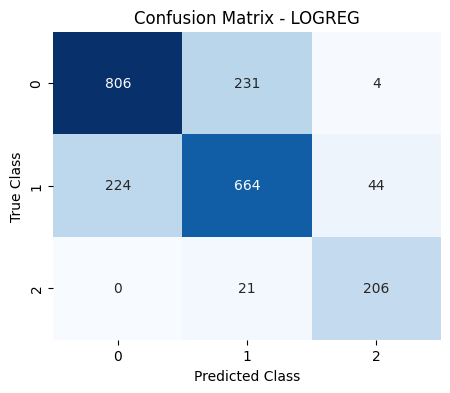

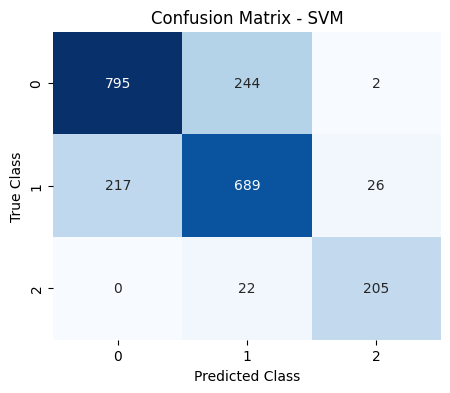

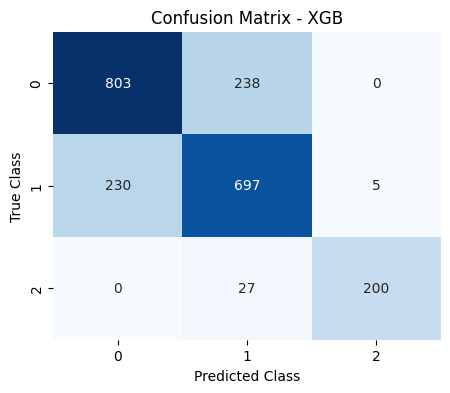

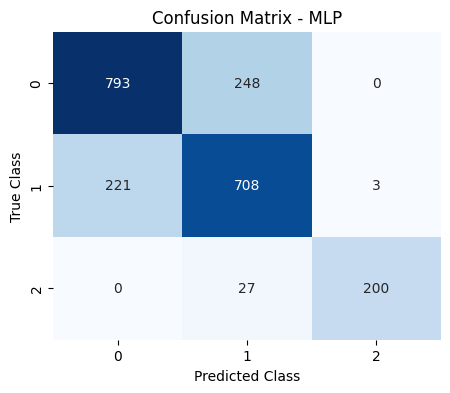

In [11]:
model_names = []
cv_macro_f1_scores = []
test_macro_f1_scores = []

for name, grid in results.items():
    model_names.append(name.upper())
    cv_macro_f1_scores.append(grid.best_score_)
    y_pred = grid.predict(X_test)
    test_macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

if model_names:
    x = range(len(model_names))
    width = 0.35

    plt.figure(figsize=(10, 5))

    plt.bar([i - width/2 for i in x], cv_macro_f1_scores, width, label="CV Macro-F1")
    plt.bar([i + width/2 for i in x], test_macro_f1_scores, width, label="Test Macro-F1")

    for i in x:
        plt.text(i - width/2, cv_macro_f1_scores[i] + 0.002, f"{cv_macro_f1_scores[i]:.3f}", ha="center")
        plt.text(i + width/2, test_macro_f1_scores[i] + 0.002, f"{test_macro_f1_scores[i]:.3f}", ha="center")

    plt.xticks(x, model_names)
    all_scores = cv_macro_f1_scores + test_macro_f1_scores
    plt.ylim(min(all_scores) - 0.01, 1)

    plt.xlabel("Model")
    plt.ylabel("Macro-F1 Score")
    plt.title("CV vs Test Macro-F1 Scores per Model")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()

for name, grid in results.items():
    y_pred = grid.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name.upper()}")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()


In [12]:
best_model_name = max(results, key=lambda x: results[x].best_score_)
best_model = results[best_model_name].best_estimator_

print(f"\nBest overall model: {best_model_name.upper()}")

y_pred = best_model.predict(X_test)

print("\nTest set performance:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))



Best overall model: XGB

Test set performance:
              precision    recall  f1-score   support

         Low       0.78      0.77      0.77      1041
    Moderate       0.72      0.75      0.74       932
        High       0.98      0.88      0.93       227

    accuracy                           0.77      2200
   macro avg       0.83      0.80      0.81      2200
weighted avg       0.78      0.77      0.77      2200




Feature importance for XGB:


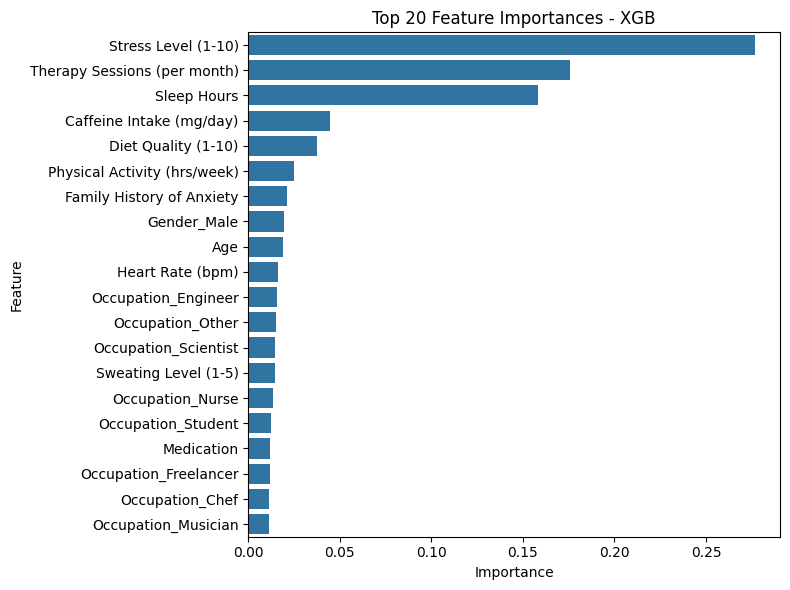

In [13]:
name = "xgb"
pipe = results[name].best_estimator_

print(f"\nFeature importance for {name.upper()}:")

try:
    feature_names = pipe["preprocess"].get_feature_names_out()
    feature_names = [f.split("__")[-1] for f in feature_names]
except:
    feature_names = X_train.columns.tolist()

importances = pipe["model"].feature_importances_

if len(importances) != len(feature_names):
    feature_names = [f"Feature {i+1}" for i in range(len(importances))]

feat_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=feat_df)
plt.title(f"Top 20 Feature Importances - {name.upper()}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [14]:
best_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [ ]:
joblib.dump(best_model, "categorical_model.pkl")

['model.pkl']